In [33]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Global Configuration

Update `DATASET_ROOT` to your local extracted dataset folder.

Expected structure:
`DATASET_ROOT/class_name/image1.jpg`

In [34]:
import os
from pathlib import Path
import torch

# =========================
# SET THIS PATH TO YOUR LOCAL EXTRACTED DATASET
# Example Windows: Path(r"D:\datasets\kvasir-capsule")
# Example Linux/Mac: Path("/home/yourname/datasets/kvasir-capsule")
# =========================
DATASET_ROOT = Path(r"E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images")

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"DATASET_ROOT does not exist: {DATASET_ROOT}")

# Auto-detect first directory containing class subfolders
actual_root = DATASET_ROOT
for root, dirs, files in os.walk(DATASET_ROOT):
    if len(dirs) > 0:
        actual_root = Path(root)
        break
DATASET_ROOT = actual_root

OUTPUT_DIR = Path("./wce_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0   # safer default for local Jupyter (especially Windows)
EPOCHS = 5
UNDERSAMPLE_THRESHOLD = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Detected DATASET_ROOT: {DATASET_ROOT}")

# Quick folder check
class_dirs = [p.name for p in DATASET_ROOT.iterdir() if p.is_dir()]
print(f"Found {len(class_dirs)} class folders. Sample: {class_dirs[:10]}")

Using device: cpu
Detected DATASET_ROOT: E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images
Found 15 class folders. Sample: ['ampulla_of_vater', 'angiectasia', 'blood_fresh', 'blood_hematin', 'erosion', 'erythema', 'foreign_body', 'ileocecal_valve', 'labelled_images', 'lymphangiectasia']


In [35]:
from pathlib import Path

p = Path(r"E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\labelled_images")
print("Exists:", p.exists())
print("Listing first 50 items:")
for i, x in enumerate(p.iterdir()):
    print(i, x.name)
    if i >= 49:
        break

Exists: True
Listing first 50 items:
0 ampulla_of_vater.tar.gz
1 angiectasia.tar.gz
2 blood_fresh.tar.gz
3 blood_hematin.tar.gz
4 erosion.tar.gz
5 erythema.tar.gz
6 foreign_body.tar.gz
7 ileocecal_valve.tar.gz
8 lymphangiectasia.tar.gz
9 normal_clean_mucosa.tar.gz
10 polyp.tar.gz
11 pylorus.tar.gz
12 reduced_mucosal_view.tar.gz
13 ulcer.tar.gz


In [36]:
for pat in ["*.tar", "*.tar.gz", "*.gz", "*.*"]:
    files = list(p.glob(pat))
    print(pat, "=>", len(files))
    if files:
        print("sample:", files[:5])

*.tar => 0
*.tar.gz => 14
sample: [WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/ampulla_of_vater.tar.gz'), WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/angiectasia.tar.gz'), WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/blood_fresh.tar.gz'), WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/blood_hematin.tar.gz'), WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/erosion.tar.gz')]
*.gz => 14
sample: [WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/ampulla_of_vater.tar.gz'), WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/angiectasia.tar.gz'), WindowsPath('E:/Semester 6/DL LAB/Mini Project/kvasir-capsule-labeled-images/labelled_images/blood_fresh.tar.gz'), WindowsPath('E:/S

In [ ]:
import tarfile
from pathlib import Path

base_root = Path(r"E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images")
tar_dir = base_root / "labelled_images"

tar_files = list(tar_dir.glob("*.tar.gz"))
print(f"Found {len(tar_files)} .tar.gz files")

for tar_path in tar_files:
    class_name = tar_path.name.replace(".tar.gz", "")
    out_dir = base_root / class_name
    out_dir.mkdir(parents=True, exist_ok=True)

    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=out_dir)

    print(f"Extracted: {tar_path.name} -> {out_dir}")

print("Extraction complete.")

In [38]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
img_count = sum(1 for f in base_root.rglob("*") if f.is_file() and f.suffix.lower() in IMG_EXTS)
print("Total images found:", img_count)

Total images found: 47238


kvasir-capsule-labeled-image 
Medical Imaging dataset used in gastrointestinal (GI) analysis, especially for capsule endoscopy.
Total images : 47238
Classes : 14 label

In [39]:
from pathlib import Path

base_root = Path(r"E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images")

print("Top-level dirs after extraction:")
for p in base_root.iterdir():
    if p.is_dir():
        print("-", p.name)

print("\nFind some jpg recursively:")
samples = list(base_root.rglob("*.jpg"))[:10]
print("jpg found:", len(samples))
for s in samples:
    print(s)

Top-level dirs after extraction:
- ampulla_of_vater
- angiectasia
- blood_fresh
- blood_hematin
- erosion
- erythema
- foreign_body
- ileocecal_valve
- labelled_images
- lymphangiectasia
- normal_clean_mucosa
- polyp
- pylorus
- reduced_mucosal_view
- ulcer

Find some jpg recursively:
jpg found: 10
E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\ulcer\Ulcer\2fc3db471f9d44c0_1252.jpg
E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\ulcer\Ulcer\2fc3db471f9d44c0_1253.jpg
E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\ulcer\Ulcer\2fc3db471f9d44c0_1720.jpg
E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\ulcer\Ulcer\2fc3db471f9d44c0_1721.jpg
E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\ulcer\Ulcer\2fc3db471f9d44c0_1722.jpg
E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\ulcer\Ulcer\2fc3db471f9d44c0_1723.jpg
E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\ulcer\Ulcer\2fc3db471f9d

In [40]:
DATASET_ROOT = Path(r"E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images")

In [41]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
img_count = sum(
    1 for f in DATASET_ROOT.rglob("*")
    if f.is_file() and f.suffix.lower() in IMG_EXTS
)
print("Total images found:", img_count)

Total images found: 47238


In [53]:
from PIL import Image, UnidentifiedImageError
from pathlib import Path
import pandas as pd

def filter_valid_images(df: pd.DataFrame) -> pd.DataFrame:
    valid_rows = []
    bad_files = []

    for _, row in df.iterrows():
        fp = Path(row["filepath"])
        try:
            with Image.open(fp) as img:
                img.verify()  # checks integrity
            valid_rows.append(row)
        except (UnidentifiedImageError, OSError, ValueError):
            bad_files.append(str(fp))

    clean_df = pd.DataFrame(valid_rows).reset_index(drop=True)

    print(f"Original rows: {len(df)}")
    print(f"Valid rows:    {len(clean_df)}")
    print(f"Bad files:     {len(bad_files)}")
    if bad_files:
        print("Sample bad files:")
        for p in bad_files[:10]:
            print(" -", p)

    return clean_df, bad_files

## Utility Functions

In [42]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def build_metadata(root: Path) -> pd.DataFrame:
    rows = []
    if not root.exists():
        raise FileNotFoundError(f"Dataset path does not exist: {root}")

    for fp in root.rglob("*"):
        if fp.is_file() and fp.suffix.lower() in IMG_EXTS:
            rows.append({"filepath": str(fp), "label": fp.parent.name})

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No images found under {root}. Check extracted structure.")
    return df

def plot_distribution(df: pd.DataFrame, title: str, save_name: str = None):
    counts = df["label"].value_counts().sort_values(ascending=False)
    ax = counts.plot(kind="bar", color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if save_name:
        plt.savefig(OUTPUT_DIR / save_name, dpi=200)
    plt.show()

def stratified_split(df: pd.DataFrame, seed: int = 42):
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        stratify=df["label"],
        random_state=seed,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["label"],
        random_state=seed,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

def random_under_sample(df: pd.DataFrame, threshold: int, seed: int = 42):
    sampled_parts = []
    rng = np.random.default_rng(seed)
    for _, part in df.groupby("label"):
        if len(part) > threshold:
            idx = rng.choice(part.index.values, size=threshold, replace=False)
            sampled_parts.append(part.loc[idx])
        else:
            sampled_parts.append(part)
    out = pd.concat(sampled_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

def build_augmented_to_threshold(df: pd.DataFrame, threshold: int, seed: int = 42):
    base = df.copy()
    base["augmented"] = False
    rng = np.random.default_rng(seed)
    extras = []
    counts = base["label"].value_counts().to_dict()
    for label, count in counts.items():
        if count < threshold:
            need = threshold - count
            label_rows = base[base["label"] == label]
            sampled_idx = rng.choice(label_rows.index.values, size=need, replace=True)
            extra = label_rows.loc[sampled_idx].copy()
            extra["augmented"] = True
            extras.append(extra)
    if extras:
        out = pd.concat([base] + extras).sample(frac=1, random_state=seed).reset_index(drop=True)
    else:
        out = base.sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

## Task 1: Dataset Exploration & Imbalance Analysis
1. Load WCE dataset
2. Plot class distribution
3. Identify majority/minority classes

Total images: 47238
Total classes: 14


,filepath,label
0,E:\Semester 6\DL LAB\Mini Project\kvasir-capsu...,Ulcer
1,E:\Semester 6\DL LAB\Mini Project\kvasir-capsu...,Ulcer
2,E:\Semester 6\DL LAB\Mini Project\kvasir-capsu...,Ulcer
3,E:\Semester 6\DL LAB\Mini Project\kvasir-capsu...,Ulcer
4,E:\Semester 6\DL LAB\Mini Project\kvasir-capsu...,Ulcer


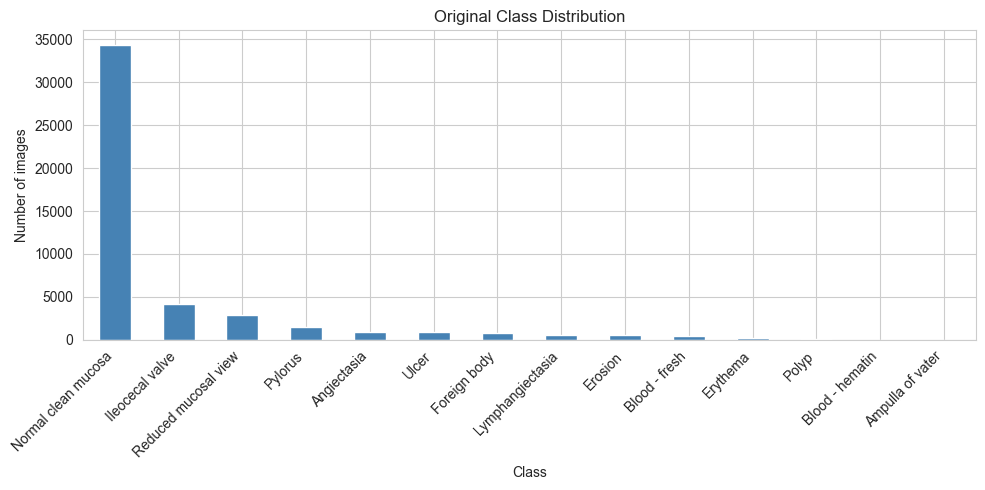

Majority class: Normal clean mucosa ( 34338 images )
Minority class: Ampulla of vater ( 10 images )
Class counts:
 label
Normal clean mucosa     34338
Ileocecal valve          4189
Reduced mucosal view     2906
Pylorus                  1529
Angiectasia               866
Ulcer                     854
Foreign body              776
Lymphangiectasia          592
Erosion                   506
Blood - fresh             446
Erythema                  159
Polyp                      55
Blood - hematin            12
Ampulla of vater           10
Name: count, dtype: int64


In [43]:
metadata_df = build_metadata(DATASET_ROOT)
print(f"Total images: {len(metadata_df)}")
print(f"Total classes: {metadata_df['label'].nunique()}")
display(metadata_df.head())

plot_distribution(metadata_df, "Original Class Distribution", "task1_original_distribution.png")

class_counts = metadata_df["label"].value_counts().sort_values(ascending=False)
majority_class = class_counts.index[0]
minority_class = class_counts.index[-1]

print("Majority class:", majority_class, "(", class_counts.iloc[0], "images )")
print("Minority class:", minority_class, "(", class_counts.iloc[-1], "images )")
print("Class counts:\n", class_counts)

## Task 2: Under-Sampling
- Randomly reduce majority classes to a fixed threshold (`UNDERSAMPLE_THRESHOLD`)
- Keep all minority samples

Original dataset size: 47238
Under-sampled dataset size: 2236


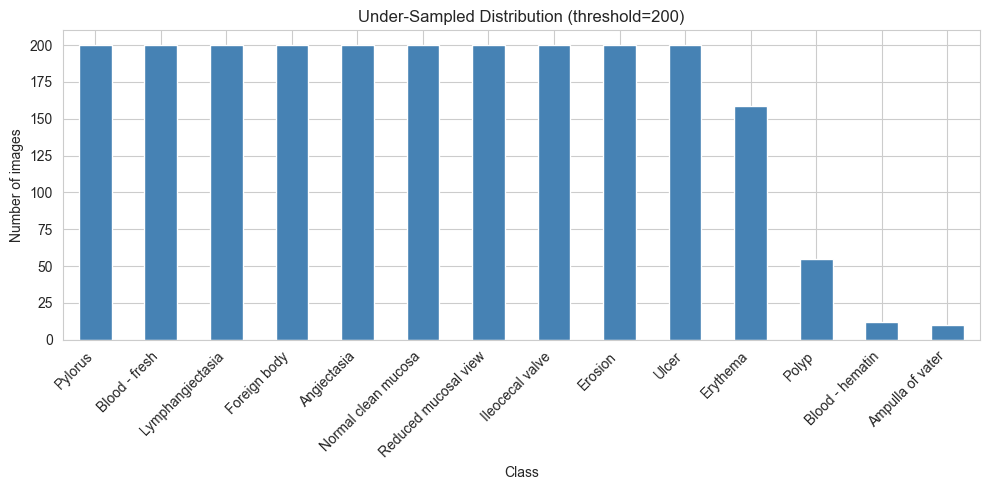

In [44]:
under_df_all = random_under_sample(metadata_df, threshold=UNDERSAMPLE_THRESHOLD, seed=SEED)
print("Original dataset size:", len(metadata_df))
print("Under-sampled dataset size:", len(under_df_all))

plot_distribution(
    under_df_all,
    f"Under-Sampled Distribution (threshold={UNDERSAMPLE_THRESHOLD})",
    "task2_undersampled_distribution.png"
)

## Task 3: Data Augmentation–Based Over-Sampling (Minority Classes Only)

Required augmentations:
- Horizontal flip
- Rotation (±20°)
- Width/Height shift (0.2)
- Zoom (0.2)

Under-sampled size: 2236
Under-sampled + augmentation-expanded size: 2800


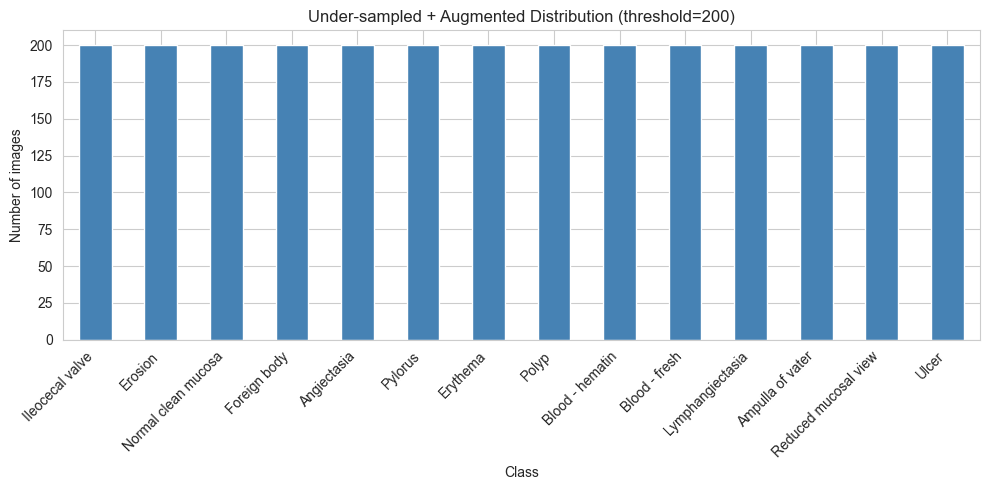

Dataset size summary
Original: 47238
Under-sampled: 2236
Under-sampled + augmentation-expanded: 2800


In [45]:
minority_aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
])

under_aug_df_all = build_augmented_to_threshold(under_df_all, threshold=UNDERSAMPLE_THRESHOLD, seed=SEED)
print("Under-sampled size:", len(under_df_all))
print("Under-sampled + augmentation-expanded size:", len(under_aug_df_all))

plot_distribution(
    under_aug_df_all,
    f"Under-sampled + Augmented Distribution (threshold={UNDERSAMPLE_THRESHOLD})",
    "task3_under_aug_distribution.png"
)

print("Dataset size summary")
print("Original:", len(metadata_df))
print("Under-sampled:", len(under_df_all))
print("Under-sampled + augmentation-expanded:", len(under_aug_df_all))

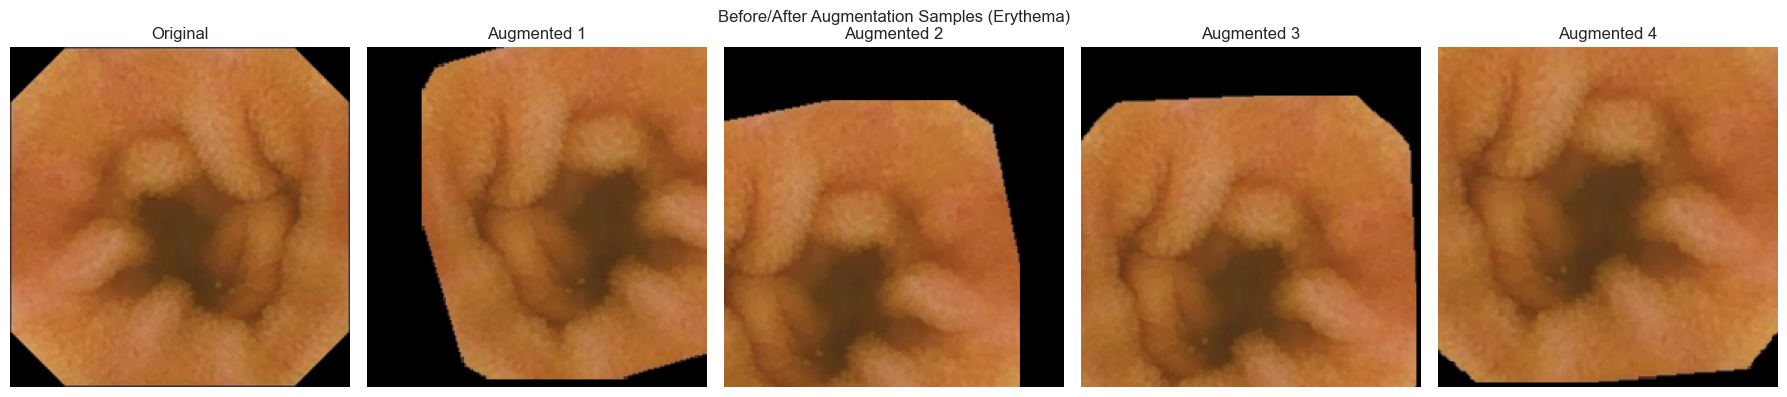

In [46]:
counts_under = under_df_all["label"].value_counts()
minority_labels = counts_under[counts_under < UNDERSAMPLE_THRESHOLD].index.tolist()
if len(minority_labels) == 0:
    minority_labels = [counts_under.index[-1]]

sample_label = minority_labels[0]
sample_path = under_df_all[under_df_all["label"] == sample_label].iloc[0]["filepath"]
img = Image.open(sample_path).convert("RGB")

augmented_images = [minority_aug_transform(img) for _ in range(4)]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
axes[0].set_title("Original")
axes[0].axis("off")

for i, aug_img in enumerate(augmented_images, start=1):
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")

plt.suptitle(f"Before/After Augmentation Samples ({sample_label})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "task3_before_after_augmentation.png", dpi=200)
plt.show()

## Task 4: Data Preprocessing
- Resize to 224×224
- Normalize pixel values
- Split into Train 70% / Validation 15% / Test 15%

In [55]:
train_df_raw, val_df, test_df = stratified_split(metadata_df, seed=SEED)

print("Split sizes:")
print("Train:", len(train_df_raw), f"({len(train_df_raw)/len(metadata_df):.2%})")
print("Validation:", len(val_df), f"({len(val_df)/len(metadata_df):.2%})")
print("Test:", len(test_df), f"({len(test_df)/len(metadata_df):.2%})")

class_names = sorted(metadata_df["label"].unique().tolist())
label_to_idx = {c: i for i, c in enumerate(class_names)}
print("Classes:", class_names)

Split sizes:
Train: 33066 (70.00%)
Validation: 7086 (15.00%)
Test: 7086 (15.00%)
Classes: ['Ampulla of vater', 'Angiectasia', 'Blood - fresh', 'Blood - hematin', 'Erosion', 'Erythema', 'Foreign body', 'Ileocecal valve', 'Lymphangiectasia', 'Normal clean mucosa', 'Polyp', 'Pylorus', 'Reduced mucosal view', 'Ulcer']


In [54]:
train_df_raw, bad_train = filter_valid_images(train_df_raw)
val_df, bad_val = filter_valid_images(val_df)
test_df, bad_test = filter_valid_images(test_df)

Original rows: 33066
Valid rows:    33066
Bad files:     0
Original rows: 7086
Valid rows:    7086
Bad files:     0
Original rows: 7086
Valid rows:    7085
Bad files:     1
Sample bad files:
 - E:\Semester 6\DL LAB\Mini Project\kvasir-capsule-labeled-images\reduced_mucosal_view\Reduced mucosal view\c11b28a8b2344716_81864.jpg


In [56]:
# ImageNet normalization (recommended for pretrained torchvision models)
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ImageTableDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label_to_idx: dict, base_transform, aug_transform=None):
        self.df = df.reset_index(drop=True).copy()
        if "augmented" not in self.df.columns:
            self.df["augmented"] = False
        self.label_to_idx = label_to_idx
        self.base_transform = base_transform
        self.aug_transform = aug_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
    # retry loop for occasional unreadable file
        for _ in range(5):
            row = self.df.iloc[idx]
            try:
                img = Image.open(row["filepath"]).convert("RGB")
                use_aug = bool(row.get("augmented", False)) and (self.aug_transform is not None)
                x = self.aug_transform(img) if use_aug else self.base_transform(img)
                y = self.label_to_idx[row["label"]]
                return x, y
            except Exception:
                idx = (idx + 1) % len(self.df)
        raise RuntimeError("Too many unreadable images encountered.")

def make_loader(df, is_train=False, shuffle=False):
    ds = ImageTableDataset(
        df=df,
        label_to_idx=label_to_idx,
        base_transform=base_transform,
        aug_transform=train_aug_transform if is_train else None,
    )
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

## Task 5: Transfer Learning with Three Models
Models:
1. EfficientNet-B0
2. MobileNetV3-Small
3. ResNet101

For each model:
- load ImageNet weights
- freeze early layers
- replace classifier head
- add Dropout and L2 regularization

In [63]:
def set_trainable_last_fraction(model, frac=0.3):
    params = list(model.parameters())
    cut = int((1 - frac) * len(params))
    for i, p in enumerate(params):
        p.requires_grad = (i >= cut)

def create_model(model_name: str, num_classes: int, dropout_p: float = 0.3):
    model_name = model_name.lower()

    if model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
        # Original classifier: [Linear, Hardswish, Dropout, Linear]
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        model.classifier[2] = nn.Dropout(p=dropout_p, inplace=True)

    elif model_name == "resnet101":
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    set_trainable_last_fraction(model, frac=0.3)
    return model.to(DEVICE)

In [50]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    running_loss = 0.0
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(y.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="macro", zero_division=0
    )
    return epoch_loss, acc, precision, recall, f1

@torch.no_grad()
def evaluate_model(model, loader, criterion):
    return run_epoch(model, loader, criterion, optimizer=None)

In [64]:
# Build train variants from train split only (best practice)
train_under = random_under_sample(train_df_raw, threshold=UNDERSAMPLE_THRESHOLD, seed=SEED)
train_under_aug = build_augmented_to_threshold(train_under, threshold=UNDERSAMPLE_THRESHOLD, seed=SEED)

# Add augmented flag to original train set for consistency
train_original = train_df_raw.copy()
train_original["augmented"] = False

train_under = train_under.copy()
if "augmented" not in train_under.columns:
    train_under["augmented"] = False

val_df_local = val_df.copy()
val_df_local["augmented"] = False
test_df_local = test_df.copy()
test_df_local["augmented"] = False

loaders = {
    "original": {
        "train": make_loader(train_original, is_train=False, shuffle=True),
        "val": make_loader(val_df_local, is_train=False, shuffle=False),
        "test": make_loader(test_df_local, is_train=False, shuffle=False),
    },
    "under": {
        "train": make_loader(train_under, is_train=False, shuffle=True),
        "val": make_loader(val_df_local, is_train=False, shuffle=False),
        "test": make_loader(test_df_local, is_train=False, shuffle=False),
    },
    "under+aug": {
        "train": make_loader(train_under_aug, is_train=True, shuffle=True),
        "val": make_loader(val_df_local, is_train=False, shuffle=False),
        "test": make_loader(test_df_local, is_train=False, shuffle=False),
    }
}

In [ ]:
# Cell 22 v1
# # Quick debug run first
# model_names = ["efficientnet_b0"]   # later add "mobilenet_v3_small", "resnet101"
# dataset_versions = ["original"]      # later add "under", "under+aug"

# results = []
# best_models = {}

# for dver in dataset_versions:
#     for mname in model_names:
#         print(f"\n=== Training {mname} on {dver} dataset ===")
#         model = create_model(mname, num_classes=len(class_names), dropout_p=0.3)

#         criterion = nn.CrossEntropyLoss()
#         optimizer = optim.Adam(
#             filter(lambda p: p.requires_grad, model.parameters()),
#             lr=LEARNING_RATE,
#             weight_decay=WEIGHT_DECAY
#         )

#         best_val_f1 = -1
#         best_state = copy.deepcopy(model.state_dict())

#         for epoch in range(1, EPOCHS + 1):
#             tr = run_epoch(model, loaders[dver]["train"], criterion, optimizer=optimizer)
#             va = evaluate_model(model, loaders[dver]["val"], criterion)
#             print(f"Epoch {epoch}/{EPOCHS} | "
#                   f"Train Loss {tr[0]:.4f} F1 {tr[4]:.4f} | "
#                   f"Val Loss {va[0]:.4f} F1 {va[4]:.4f}")

#             if va[4] > best_val_f1:
#                 best_val_f1 = va[4]
#                 best_state = copy.deepcopy(model.state_dict())

#         model.load_state_dict(best_state)
#         te = evaluate_model(model, loaders[dver]["test"], criterion)

#         row = {
#             "dataset_version": dver,
#             "model": mname,
#             "test_loss": te[0],
#             "accuracy": te[1],
#             "macro_precision": te[2],
#             "macro_recall": te[3],
#             "macro_f1": te[4],
#         }
#         results.append(row)
#         best_models[(dver, mname)] = copy.deepcopy(model.state_dict())

#         print(f"Test -> Acc: {te[1]:.4f}, Prec: {te[2]:.4f}, Recall: {te[3]:.4f}, F1: {te[4]:.4f}")


=== Training efficientnet_b0 on original dataset ===
Epoch 1/5 | Train Loss 0.3206 F1 0.6122 | Val Loss 0.1713 F1 0.7660
Epoch 2/5 | Train Loss 0.1654 F1 0.7484 | Val Loss 0.1058 F1 0.7572
Epoch 3/5 | Train Loss 0.1408 F1 0.7881 | Val Loss 0.1106 F1 0.7947
Epoch 4/5 | Train Loss 0.1230 F1 0.7798 | Val Loss 0.0996 F1 0.7814
Epoch 5/5 | Train Loss 0.1060 F1 0.7913 | Val Loss 0.0704 F1 0.8392
Test -> Acc: 0.9822, Prec: 0.8960, Recall: 0.8850, F1: 0.8893


In [ ]:
# Cell 22 v2

model_names = ["efficientnet_b0", "mobilenet_v3_small", "resnet101"]
dataset_versions = ["original", "under", "under+aug"]

results = []
best_models = {}
histories = {}  # (dataset_version, model_name) -> dict of per-epoch metrics

for dver in dataset_versions:
    for mname in model_names:
        print(f"\n=== Training {mname} on {dver} dataset ===")
        model = create_model(mname, num_classes=len(class_names), dropout_p=0.3)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )

        # Intelligent LR control: reduce LR when val loss plateaus
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )

        best_val_f1 = -1
        best_state = copy.deepcopy(model.state_dict())

        # history for plots
        hist = {
            "epoch": [],
            "train_loss": [],
            "val_loss": [],
            "train_f1": [],
            "val_f1": [],
            "lr": []
        }

        for epoch in range(1, EPOCHS + 1):
            tr = run_epoch(model, loaders[dver]["train"], criterion, optimizer=optimizer)
            va = evaluate_model(model, loaders[dver]["val"], criterion)

            # Step scheduler on validation loss
            scheduler.step(va[0])

            current_lr = optimizer.param_groups[0]["lr"]

            hist["epoch"].append(epoch)
            hist["train_loss"].append(tr[0])
            hist["val_loss"].append(va[0])
            hist["train_f1"].append(tr[4])
            hist["val_f1"].append(va[4])
            hist["lr"].append(current_lr)

            print(
                f"Epoch {epoch}/{EPOCHS} | "
                f"LR {current_lr:.6f} | "
                f"Train Loss {tr[0]:.4f} F1 {tr[4]:.4f} | "
                f"Val Loss {va[0]:.4f} F1 {va[4]:.4f}"
            )

            if va[4] > best_val_f1:
                best_val_f1 = va[4]
                best_state = copy.deepcopy(model.state_dict())

        model.load_state_dict(best_state)
        te = evaluate_model(model, loaders[dver]["test"], criterion)

        row = {
            "dataset_version": dver,
            "model": mname,
            "test_loss": te[0],
            "accuracy": te[1],
            "macro_precision": te[2],
            "macro_recall": te[3],
            "macro_f1": te[4],
        }
        results.append(row)
        best_models[(dver, mname)] = copy.deepcopy(model.state_dict())
        histories[(dver, mname)] = hist

        print(
            f"Test -> Acc: {te[1]:.4f}, Prec: {te[2]:.4f}, "
            f"Recall: {te[3]:.4f}, F1: {te[4]:.4f}"
        )


=== Training efficientnet_b0 on original dataset ===
Epoch 1/5 | LR 0.001000 | Train Loss 0.3160 F1 0.6038 | Val Loss 0.1240 F1 0.7359
Epoch 2/5 | LR 0.001000 | Train Loss 0.1684 F1 0.7529 | Val Loss 0.1043 F1 0.7964
Epoch 3/5 | LR 0.001000 | Train Loss 0.1370 F1 0.7951 | Val Loss 0.1165 F1 0.8032
Epoch 4/5 | LR 0.001000 | Train Loss 0.1198 F1 0.8282 | Val Loss 0.0880 F1 0.7766
Epoch 5/5 | LR 0.001000 | Train Loss 0.1054 F1 0.7866 | Val Loss 0.0647 F1 0.8066
Test -> Acc: 0.9829, Prec: 0.8298, Recall: 0.8035, F1: 0.8158

=== Training mobilenet_v3_small on original dataset ===
Epoch 1/5 | LR 0.001000 | Train Loss 0.3171 F1 0.6375 | Val Loss 0.2383 F1 0.6892
Epoch 2/5 | LR 0.001000 | Train Loss 0.1643 F1 0.7713 | Val Loss 0.1459 F1 0.8094
Epoch 3/5 | LR 0.001000 | Train Loss 0.1236 F1 0.8251 | Val Loss 0.1207 F1 0.8212
Epoch 4/5 | LR 0.001000 | Train Loss 0.1105 F1 0.8081 | Val Loss 0.0974 F1 0.8626
Epoch 5/5 | LR 0.001000 | Train Loss 0.0955 F1 0.8715 | Val Loss 0.1169 F1 0.8226
Test ->

100%|██████████| 171M/171M [00:37<00:00, 4.83MB/s] 


Epoch 1/5 | LR 0.001000 | Train Loss 0.2669 F1 0.6400 | Val Loss 0.1437 F1 0.7560
Epoch 2/5 | LR 0.001000 | Train Loss 0.1205 F1 0.7910 | Val Loss 0.0942 F1 0.8029
Epoch 3/5 | LR 0.001000 | Train Loss 0.0963 F1 0.8182 | Val Loss 0.0945 F1 0.8492
Epoch 4/5 | LR 0.001000 | Train Loss 0.0847 F1 0.8526 | Val Loss 0.0925 F1 0.8891


In [59]:
results_df = pd.DataFrame(results).sort_values(["dataset_version", "macro_f1"], ascending=[True, False]).reset_index(drop=True)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "task_results_summary.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'task_results_summary.csv'}")

,dataset_version,model,test_loss,accuracy,macro_precision,macro_recall,macro_f1
0,original,efficientnet_b0,0.055379,0.982218,0.895995,0.884992,0.889286


Saved: wce_outputs\task_results_summary.csv


Best setting:
dataset_version           original
model              efficientnet_b0
test_loss                 0.055379
accuracy                  0.982218
macro_precision           0.895995
macro_recall              0.884992
macro_f1                  0.889286
Name: 0, dtype: object


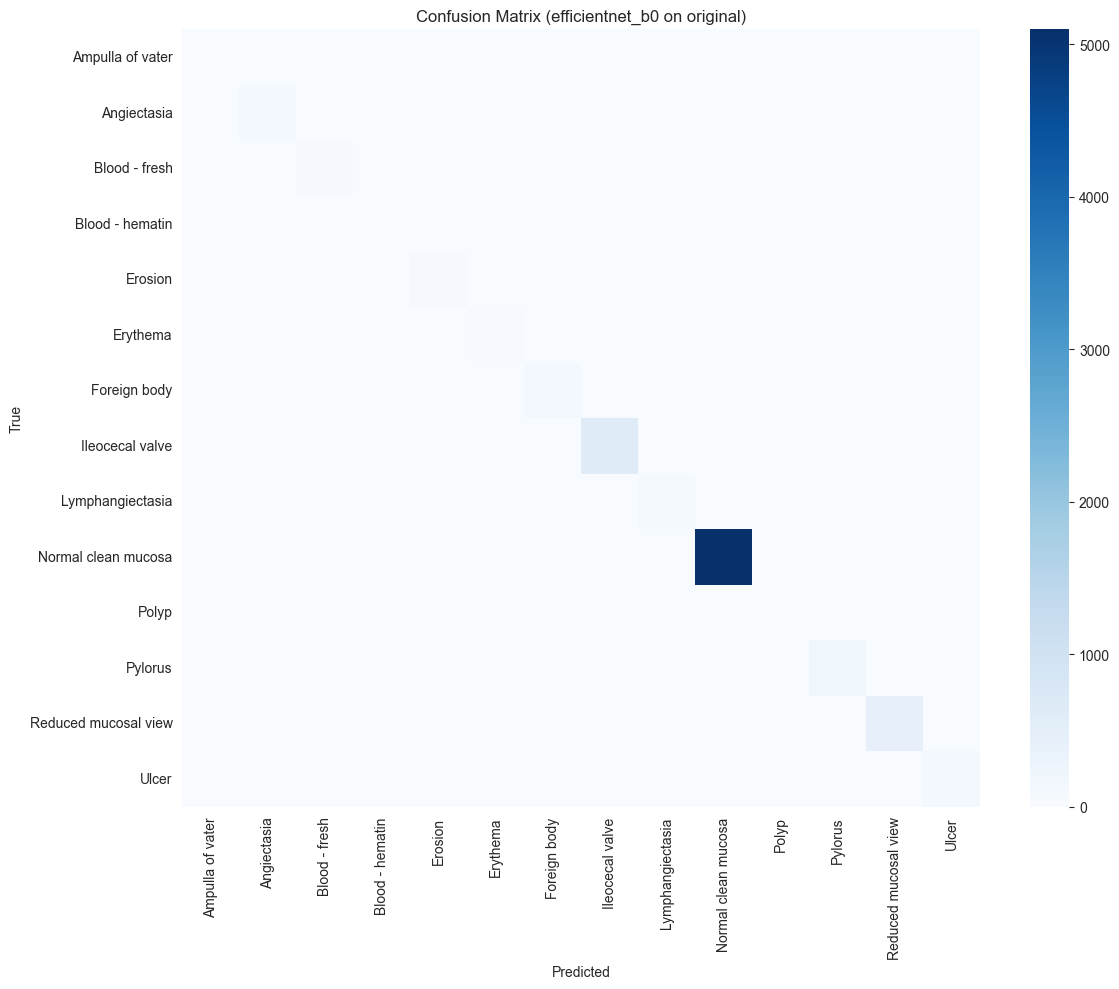

In [60]:
best_idx = results_df["macro_f1"].idxmax()
best_row = results_df.loc[best_idx]
best_dver = best_row["dataset_version"]
best_mname = best_row["model"]

print("Best setting:")
print(best_row)

best_model = create_model(best_mname, num_classes=len(class_names), dropout_p=0.3)
best_model.load_state_dict(best_models[(best_dver, best_mname)])
best_model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in loaders[best_dver]["test"]:
        x = x.to(DEVICE)
        logits = best_model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(y.numpy().tolist())

cm = confusion_matrix(all_targets, all_preds)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, cmap="Blues", annot=False)
plt.title(f"Confusion Matrix ({best_mname} on {best_dver})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_confusion_matrix.png", dpi=220)
plt.show()

## Notes
- All outputs are saved in `./wce_outputs`.
- If running on CPU, training will be slow.
- For Windows/Jupyter stability, keep `NUM_WORKERS=0`.